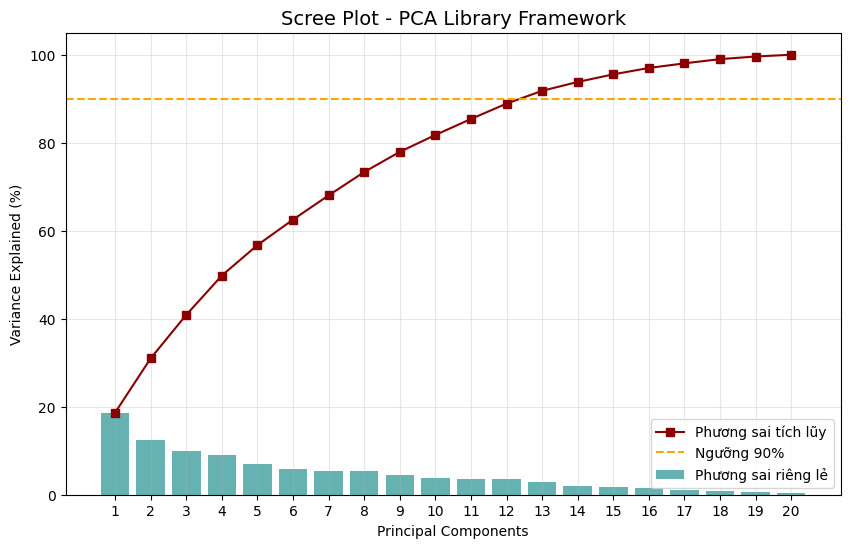

NHẬN XÉT: Sử dụng PCA giúp giảm số biến từ 20 xuống 2 thành phần chính giữ được 31.01% lượng thông tin, giúp mô hình của Phương Anh chạy nhanh và mượt hơn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Đọc dữ liệu clean
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
except:
    df = pd.read_csv('./clean/hanoi_aqi_cleaned.csv')

# 2. Loại bỏ cột AQI và lấy các cột số
X = df.drop(columns=['AQI']) if 'AQI' in df.columns else df.copy()
X = X.select_dtypes(include=[np.number]).dropna()

# 3. Chuẩn hóa bằng StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Thực hiện PCA cho TOÀN BỘ các biến (Không giới hạn n_components=2)
pca = PCA()
pca.fit(X_scaled)
exp_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

# 5. Vẽ biểu đồ Scree Plot đồng bộ với bản Manual
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color='teal', label='Phương sai riêng lẻ')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='s', color='darkred', label='Phương sai tích lũy')
plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')

plt.title('Scree Plot - PCA Library Framework', fontsize=14)
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained (%)')
plt.xticks(range(1, len(exp_var) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Nhận xét theo yêu cầu
print(f"NHẬN XÉT: Sử dụng PCA giúp giảm số biến từ {X.shape[1]} xuống 2 thành phần chính "
      f"giữ được {cum_var[1]:.2f}% lượng thông tin, giúp mô hình của Phương Anh chạy nhanh và mượt hơn.")